In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ratings = pd.read_csv("../dataset/ml-1m/ratings.dat", sep="::", engine="python", header=None, names=["userId", "movieId", "rating", "timestamp"])

In [13]:
n_users = ratings["userId"].nunique()
n_movies = ratings["movieId"].nunique()
print(n_users)
print(n_movies)

6040
3706


In [14]:
observed_ratings = len(ratings)
print(observed_ratings)

1000209


In [15]:
possible_ratings = n_users * n_movies
print(possible_ratings)

22384240


In [16]:
density = observed_ratings/possible_ratings
print(density)
print(f"{density:.4%}")

0.044683625622312845
4.4684%


In [17]:
stats = pd.DataFrame({
    'Metric': ["Users", "Movies", "Ratings", "Density"],
    'Value': [n_users, n_movies, observed_ratings, f'{density:.4%}']
})
print(stats)
stats.to_csv("../results/dataset_stats.csv", index="False")

    Metric    Value
0    Users     6040
1   Movies     3706
2  Ratings  1000209
3  Density  4.4684%


# Movie Popularity Distribution
`groupby("movieId")` looks at the ratings and group all the rows as movieId and `size` counts how many rows(ratings) are in each movies bucket and sorting the counts from the highest to lowest.

In [18]:
movie_counts = ratings.groupby("movieId").size()
movie_counts = movie_counts.sort_values(ascending=False)

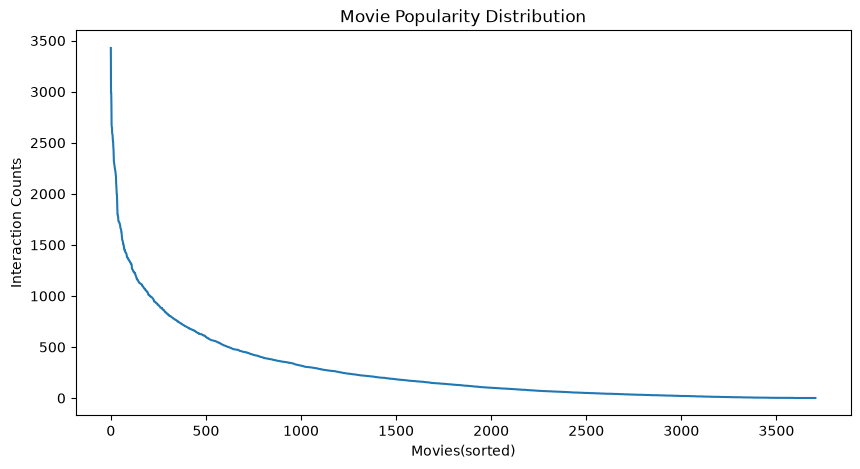

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(movie_counts.values)
plt.xlabel("Movies(sorted)")
plt.ylabel("Interaction Counts")
plt.title("Movie Popularity Distribution")
plt.show()

# User Bias (Rating Bias) (Optimistic vs Pessimistic)
Are user inherently generous or strict?. This show the Average ratings per user.
suppose A rate 5 5 4 5 -> mean is 4.75
another B rate 2 2 3 1 -> mean is 2.0
for the same movie **Movie X** 
- A gives 4 and B gives 2
Without **normalization**:
model thinks: A likes more
but in reality:
A rates everything high.
B rates everything low.
hence $$r'_{ui} =r_{ui}​−μ_u$$ subtract user average.

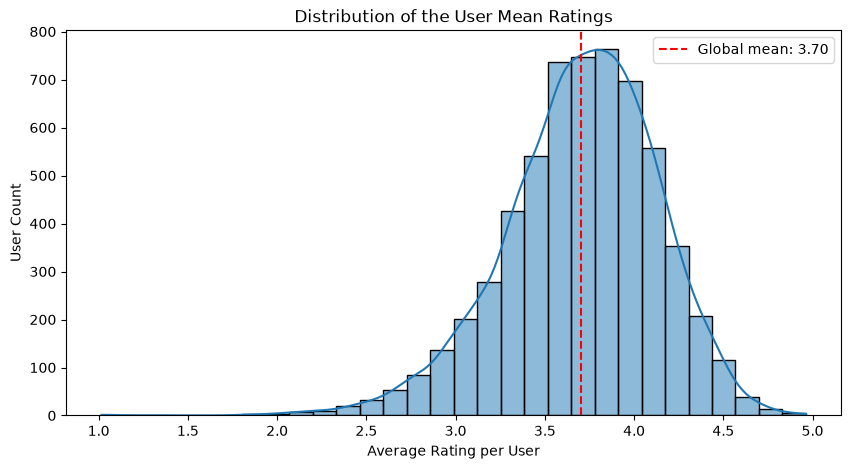

Optimistic users (mean >= 4.0): 1544
Pessimistic users (mean <= 2.5): 58


In [ ]:
user_mean = ratings.groupby("userId")["rating"].mean()
plt.figure(figsize=(10,5))
sns.histplot(user_mean, bins=30, kde=True)
plt.axvline(user_mean.mean(), color='red', linestyle='--', label=f'Global mean: {user_mean.mean():.2f}')
plt.title("Distribution of the User Mean Ratings")
plt.xlabel("Average Rating per User")
plt.ylabel("User Count")
plt.legend()
plt.tight_layout
plt.savefig("../figures/fig_01_user_bias.png", dpi=300, bbox_inches='tight')
plt.show()
# Print extremes for text
print("Optimistic users (mean >= 4.0):", (user_mean >= 4.0).sum())
print("Pessimistic users (mean <= 2.5):", (user_mean <= 2.5).sum())